# Modelación en ingeniería
## Diseño de señales de entrada

*Profesor: David Ortiz-Puerta*

---

> **💡 Nota para usuarios de Google Colab**
> 
> Antes de ejecutar el notebook, descarga las funciones auxiliares ejecutando la siguiente celda

In [ ]:
# !wget -q https://raw.githubusercontent.com/dortiz5/modelacion-en-ingenieria/main/src/helpers.py

In [21]:
import sys
sys.path.append('..')   # sube un nivel, ahora ve 'src' como paquete
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from src.helpers import (save_simulation, configure_plot_style, generate_input)

configure_plot_style()

## Modelo de Lotka-Volterra

El modelo de Lotka-Volterra describe la interacción entre dos especies en un sistema presa-depredador. Sea $x_1(t)$ la población de presas y $x_2(t)$ la de depredadores. La dinámica se rige por:

\begin{equation*}
\begin{aligned}
\dot{x}_1 &= \alpha x_1 - \beta x_1 x_2 \\
\dot{x}_2 &= \delta x_1 x_2 - \gamma x_2
\end{aligned}
\end{equation*}

donde $\alpha$ es la tasa de crecimiento de la presa en ausencia de depredador, $\gamma$ la tasa de mortalidad del depredador en ausencia de presa, y $\beta$, $\delta$ los coeficientes de interacción trófica. Para este trabajo se usan parámetros canónicos $\alpha = \beta = \gamma = \delta = 1$.

La entrada $u(t)$ se introduce como una perturbación sobre la tasa de captura $\beta$, modelando una intervención externa (cosecha, pesticida, refugio) que afecta únicamente el lado de la presa sin alterar la eficiencia de conversión del depredador:

\begin{equation*}
\begin{aligned}
\dot{x}_1 &= \alpha x_1 - (\beta + u(t)) \, x_1 x_2 \\
\dot{x}_2 &= \delta x_1 x_2 - \gamma x_2
\end{aligned}
\end{equation*}

El sistema posee dos puntos de equilibrio: el trivial $(0,0)$ y el no trivial $(x_1^*, x_2^*) = (\gamma/\delta, \, \alpha/\beta) = (1, 1)$. Este último corresponde al régimen de coexistencia y es el punto de operación de interés para identificación.

### Linealización en el equilibrio

Sean las variables de desviación $\tilde{x}_i = x_i - x_i^*$. Linealizando el sistema forzado alrededor de $(x_1^*, x_2^*)$ se obtiene:

\begin{equation*}
\begin{aligned}
\dot{\tilde{x}}_1 &= -\beta x_1^* \, \tilde{x}_2 - x_1^* x_2^* \, u(t) \\
\dot{\tilde{x}}_2 &= \delta x_2^* \, \tilde{x}_1
\end{aligned}
\end{equation*}

En forma matricial:

\begin{equation*}
\begin{bmatrix} \dot{\tilde{x}}_1 \\ \dot{\tilde{x}}_2 \end{bmatrix}
=
\underbrace{\begin{bmatrix} 0 & -\beta x_1^* \\ \delta x_2^* & 0 \end{bmatrix}}_{A}
\begin{bmatrix} \tilde{x}_1 \\ \tilde{x}_2 \end{bmatrix}
+
\underbrace{\begin{bmatrix} -x_1^* x_2^* \\ 0 \end{bmatrix}}_{B} u(t)
\end{equation*}

Los autovalores de $A$ son $\lambda_{1,2} = \pm j\sqrt{\alpha \gamma}$, puramente imaginarios. El equilibrio es por tanto un **centro**: el modelo lineal predice oscilaciones sostenidas de frecuencia natural $\omega_n = \sqrt{\alpha\gamma}$, sin amortiguamiento. El término independiente $-x_1^* x_2^* \, u(t)$ aparece porque la entrada multiplica al producto $x_1 x_2$, cuyo valor en el equilibrio es no nulo.

La linealización es válida solo en una vecindad del equilibrio. Para excursiones grandes, los modos no lineales (asimetría picos-valles, dependencia del período con la amplitud) divergen del comportamiento lineal.

In [22]:
def simulate_lotka_volterra(x0, t, sigma_noise=0.0, u=None, linear=False,
                             save=False, data_dir='../data', title = None):
    alpha, beta, gamma, delta = 1.0, 1.0, 1.0, 1.0
    x1_eq, x2_eq = gamma/delta, alpha/beta

    if u is None:
        u = np.zeros_like(t)
    u_interp = lambda ti: np.interp(ti, t, u)

    if linear:
        def rhs(ti, x):
            x1t, x2t = x
            ut = u_interp(ti)
            dx1 = -beta * x1_eq * x2t - x1_eq * x2_eq * ut
            dx2 = delta * x2_eq * x1t
            return [dx1, dx2]
        x0_sim = [x0[0] - x1_eq, x0[1] - x2_eq]
    else:
        def rhs(ti, x):
            x1, x2 = x
            ut = u_interp(ti)
            dx1 = alpha*x1 - (beta + ut)*x1*x2
            dx2 = delta*x1*x2 - gamma*x2
            return [dx1, dx2]
        x0_sim = x0

    sol = solve_ivp(rhs, (t[0], t[-1]), x0_sim, t_eval=t,
                    method='RK45', rtol=1e-8, atol=1e-10)

    x1, x2 = sol.y
    if linear:
        x1 = x1 + x1_eq
        x2 = x2 + x2_eq

    if sigma_noise > 0:
        x1 = x1 + np.random.normal(0, sigma_noise, size=x1.shape)
        x2 = x2 + np.random.normal(0, sigma_noise, size=x2.shape)

    df = pd.DataFrame({'t': t, 'u': u, 'x1': x1, 'x2': x2})

    if save:
        model_name = 'lotka_volterra_linear' if linear else 'lotka_volterra'
        if title:                                # None o '' es Falsy
            model_name = f'{model_name}_{title}'
        filepath = save_simulation(df, model_name, data_dir)
        print(f'Saved: {filepath}')

    return df

Saved: ../data/lotka_volterra/lotka_volterra_20260514_001.csv
Saved: ../data/lotka_volterra_linear/lotka_volterra_linear_20260514_001.csv


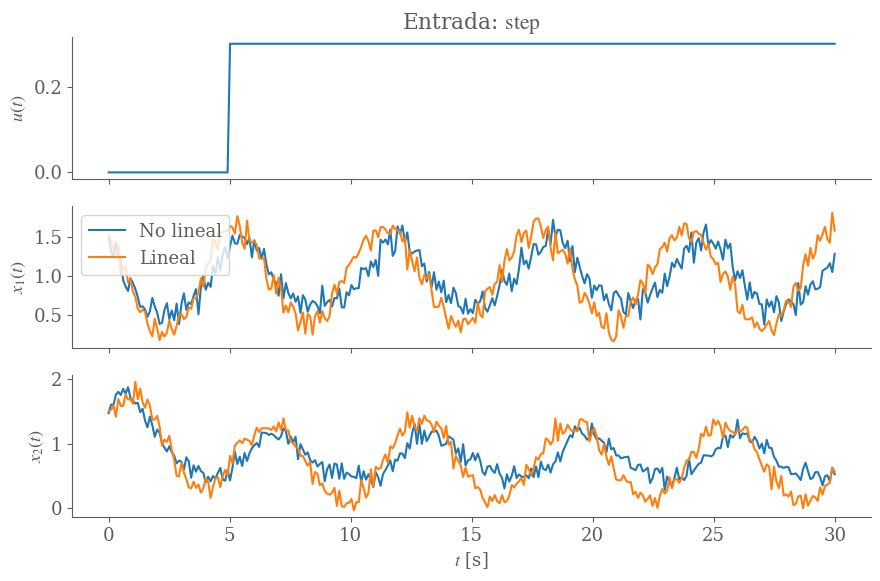

Saved: ../data/lotka_volterra/lotka_volterra_20260514_002.csv
Saved: ../data/lotka_volterra_linear/lotka_volterra_linear_20260514_002.csv


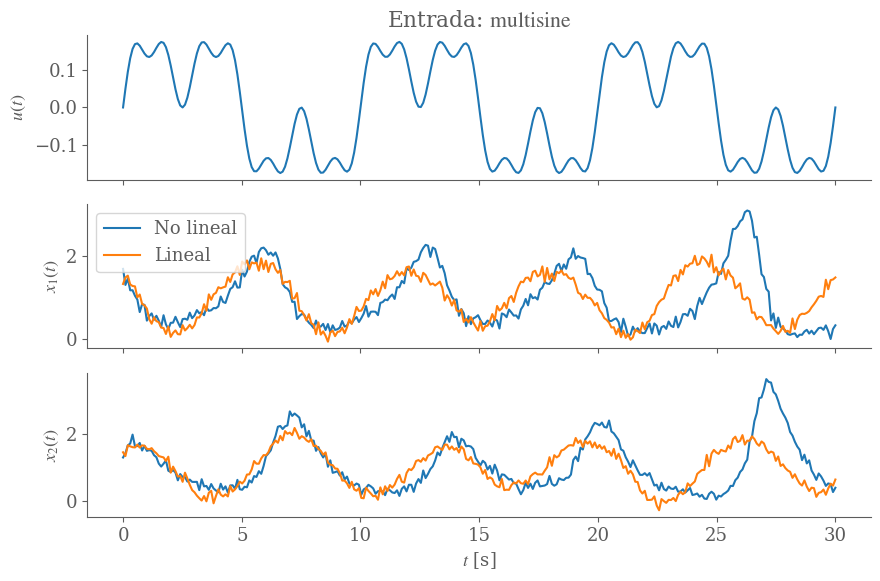

Saved: ../data/lotka_volterra/lotka_volterra_20260514_003.csv
Saved: ../data/lotka_volterra_linear/lotka_volterra_linear_20260514_003.csv


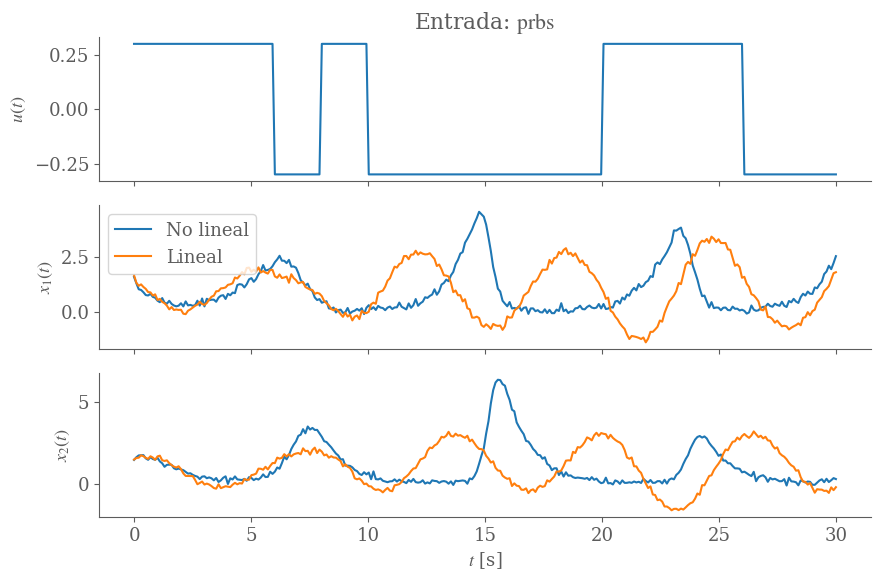

Saved: ../data/lotka_volterra/lotka_volterra_20260514_004.csv
Saved: ../data/lotka_volterra_linear/lotka_volterra_linear_20260514_004.csv


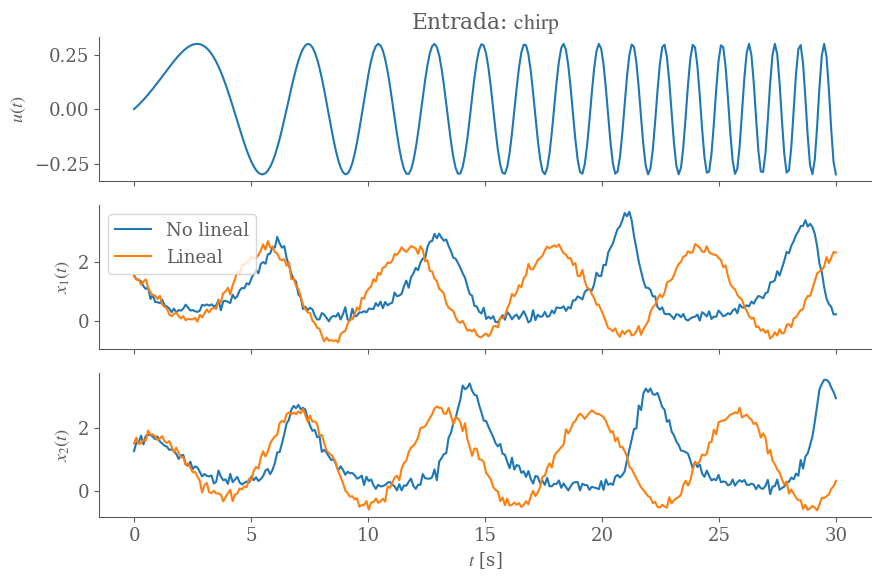

Saved: ../data/lotka_volterra/lotka_volterra_20260514_005.csv
Saved: ../data/lotka_volterra_linear/lotka_volterra_linear_20260514_005.csv


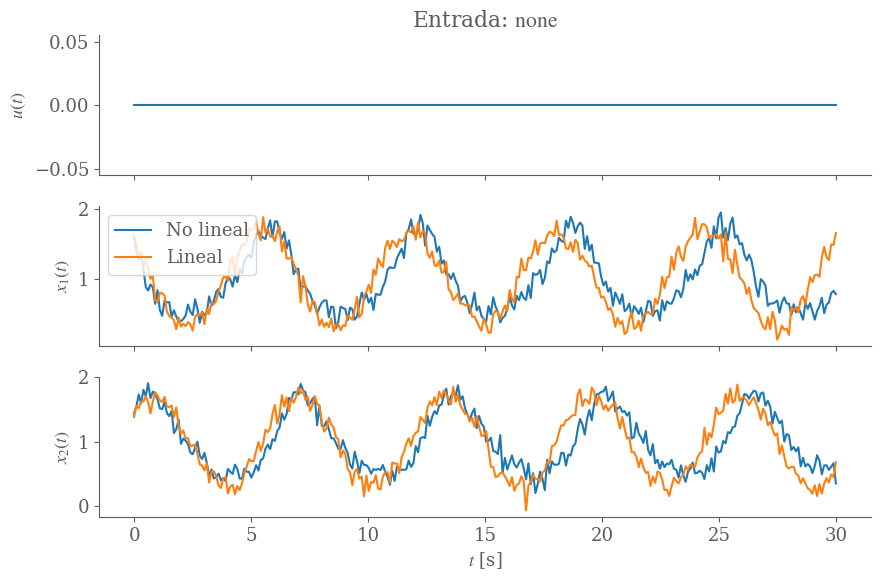

In [23]:
t = np.linspace(0, 30, 300)

u_step      = generate_input(t, 'step', t_step=5, u0=0, u1=0.3)
u_multisine = generate_input(t, 'multisine', freqs=[0.1, 0.3, 0.7], 
                                             amps=[0.15, 0.1, 0.05])
u_prbs      = generate_input(t, 'prbs', n_bits=8, t_bit=2, amplitude=0.3, seed=42)
u_chirp     = generate_input(t, 'chirp', f0=0.05, f1=1.0, amplitude=0.3)
u_none      = generate_input(t, 'none')

inputs = {'step': u_step, 'multisine': u_multisine,
          'prbs': u_prbs, 'chirp': u_chirp, 'none': u_none}

for name, u in inputs.items():
    df_nl = simulate_lotka_volterra(x0=[1.5, 1.5], t=t, sigma_noise=0.1, u=u, 
                                    linear=False, save=True)
    df_l  = simulate_lotka_volterra(x0=[1.5, 1.5], t=t, sigma_noise=0.1, u=u, 
                                    linear=True, save=True)

    fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
    axes[0].plot(df_nl['t'], df_nl['u']); axes[0].set_ylabel(r'$u(t)$'); axes[0].set_title(rf'Entrada: $\mathrm{{{name}}}$')
    axes[1].plot(df_nl['t'], df_nl['x1'], label='No lineal')
    axes[1].plot(df_l['t'],  df_l['x1'],  '-', label='Lineal')
    axes[1].set_ylabel(r'$x_1(t)$'); axes[1].legend()
    axes[2].plot(df_nl['t'], df_nl['x2'], label='No lineal')
    axes[2].plot(df_l['t'],  df_l['x2'], '-', label='Lineal')
    axes[2].set_ylabel(r'$x_2(t)$'); axes[2].set_xlabel(r'$t$ [s]')
    plt.tight_layout(); plt.show()